흥행 영화 유형 편가르기, K-평균, 비지도, 0.25 당 250만명

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 6s (1,718 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

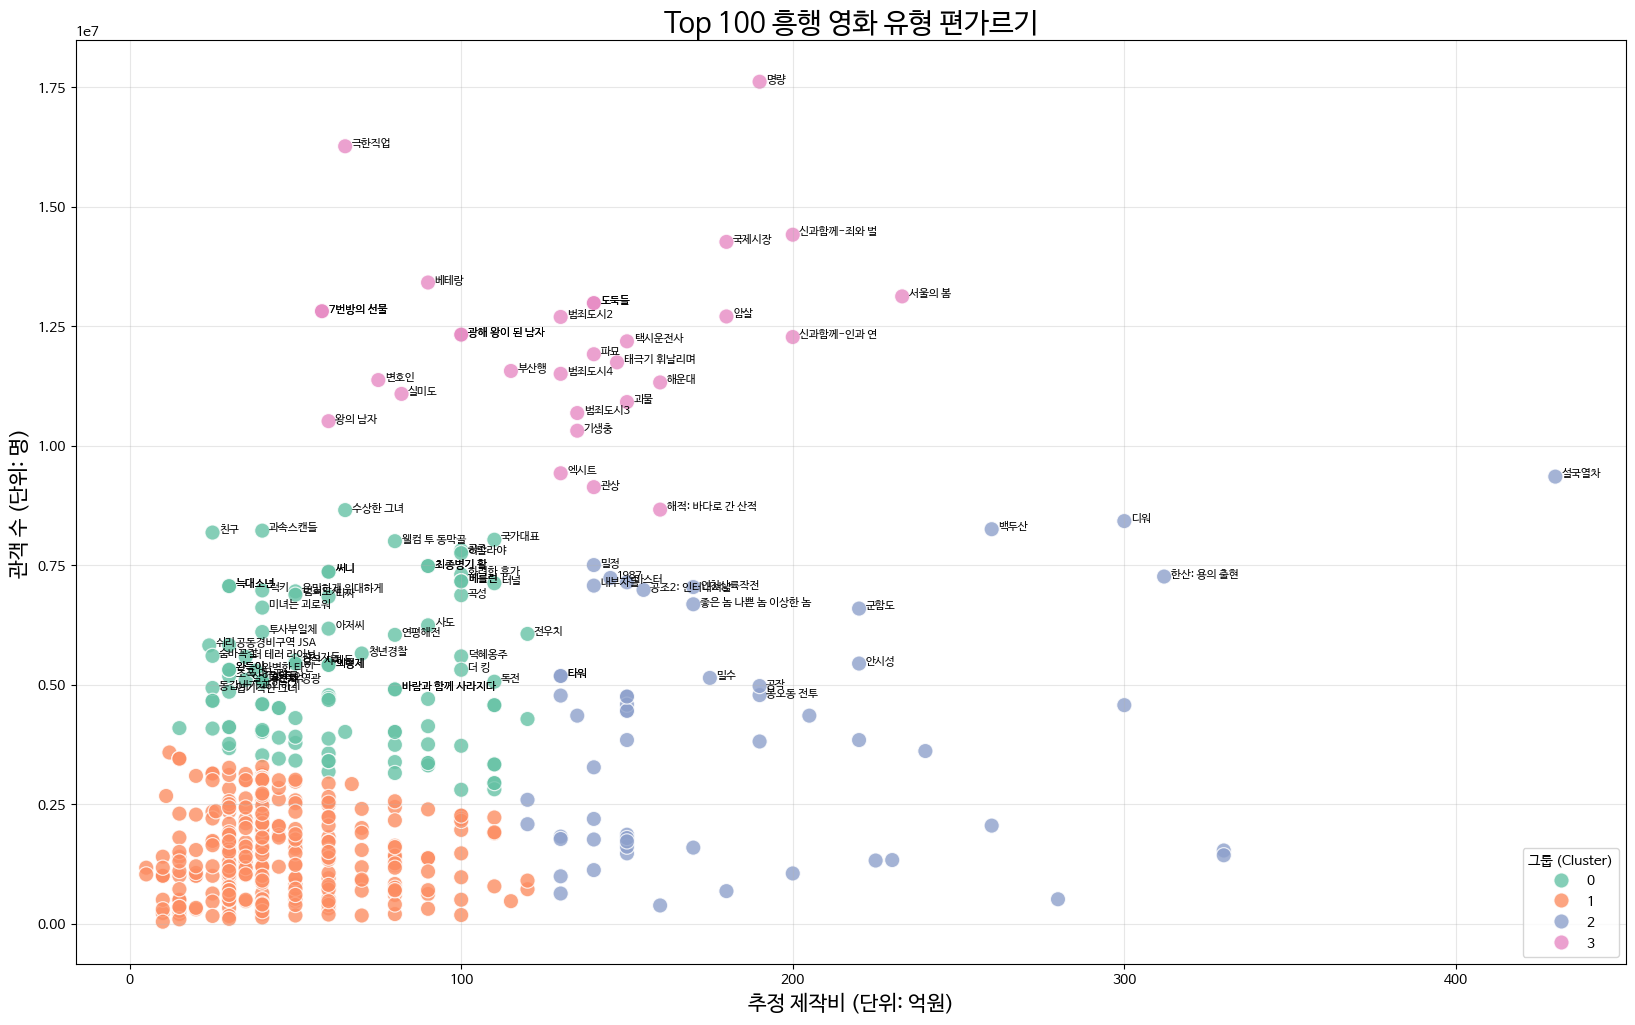

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys_font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=sys_font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

csv_path = 'top_500_korean_movies.csv'
df = pd.read_csv(csv_path)

def clean_budget(text):
    if pd.isna(text): return np.nan
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else np.nan

df['Budget(100M_KRW)'] = df['Estimated Production Budget'].apply(clean_budget)
df = df.dropna(subset=['Budget(100M_KRW)', 'Admissions'])

X = df[['Budget(100M_KRW)', 'Admissions']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(20, 12))

sns.scatterplot(x='Budget(100M_KRW)', y='Admissions', hue='Cluster',
                palette='Set2', data=df, s=120, alpha=0.8)

top_movies = df.nlargest(100, 'Admissions')
for _, row in top_movies.iterrows():
    plt.text(row['Budget(100M_KRW)'] + 2, row['Admissions'], row['Movie Name'], fontsize=8)

plt.title('Top 100 흥행 영화 유형 편가르기', fontsize=20)
plt.xlabel('추정 제작비 (단위: 억원)', fontsize=15)
plt.ylabel('관객 수 (단위: 명)', fontsize=15)
plt.legend(title='그룹 (Cluster)', loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()